Logistic → Acc:0.90 | Prec:0.00 | Recall:0.00
RandomForest → Acc:0.95 | Prec:1.00 | Recall:0.50
XGBoost → Acc:0.90 | Prec:0.00 | Recall:0.00

Best Model: RandomForest

Best Params: {'max_depth': 3, 'n_estimators': 50}


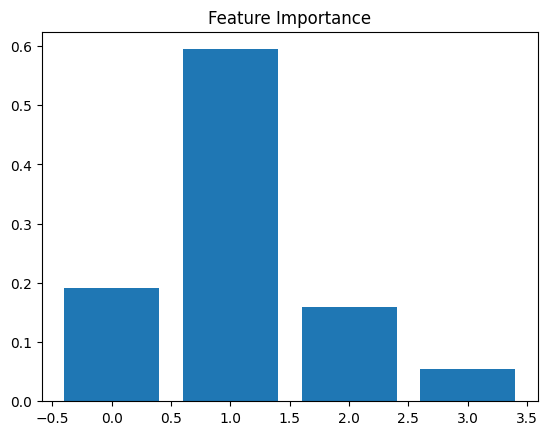


Sample Prediction: FAIL


In [5]:
import polars as pl
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score
from xgboost import XGBClassifier

data = {
    "StudyHours": np.random.randint(1, 10, 100),
    "Attendance": np.random.randint(50, 100, 100),
    "Gender": np.random.choice(["M", "F"], 100),
    "City": np.random.choice(["Delhi", "Mumbai", "Pune"], 100)
}

df = pl.DataFrame(data)

df = df.with_columns(
    ((pl.col("StudyHours")*0.4 + pl.col("Attendance")*0.6) > 60)
    .cast(pl.Int64)
    .alias("Pass")
)

le = LabelEncoder()
df = df.with_columns(pl.Series("Gender", le.fit_transform(df["Gender"].to_numpy())))
df = df.to_dummies(columns=["City"])

y = df["Pass"].to_numpy()
X = df.drop("Pass").to_numpy()

selector = SelectKBest(score_func=f_classif, k=4)
X = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)

    results[name] = acc
    trained_models[name] = model

    print(f"{name} → Acc:{acc:.2f} | Prec:{prec:.2f} | Recall:{rec:.2f}")

best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [50, 100], 'max_depth': [3, 5]},
    cv=2
)

grid.fit(X_train, y_train)
tuned_model = grid.best_estimator_

joblib.dump(tuned_model, "model.pkl")

print("\nBest Params:", grid.best_params_)

plt.bar(range(len(tuned_model.feature_importances_)), tuned_model.feature_importances_)
plt.title("Feature Importance")
plt.show()

def predict_student(data):
    model = joblib.load("model.pkl")
    data = scaler.transform(data)
    return "PASS" if model.predict(data)[0] == 1 else "FAIL"

print("\nSample Prediction:", predict_student(X_test[0:1]))